# Density-Based Spatial Clustering of Applications with Noise

### ¿Qué es?

* En Español es "Agrupamiento de Aplicionces con Ruido basado en la Densidad Espacial".
* Es un `algoritmo` de clustering `no supervisado` (como K-Means), pero en lugar de basarse en centroides, se basa en la densidad de puntos en el espacio.
* `DBSCAN` agrupa puntos que están “cerca” unos de otros (alta densidad de datos) y `separa los que están aislados` (considerados ruido u `outliers`).
* Parámetros principales
  - `ε (epsilon)` → distancia máxima para considerar que un punto es “vecino” de otro.
  - `minPts (mínimo de puntos)` → cantidad mínima de vecinos que un punto debe tener para ser considerado un punto central.
* Clasificación de puntos en `DBSCAN`
  - `Punto central`: Tiene al menos minPts vecinos dentro de la distancia ε.
  - `Punto borde`: Está dentro de la vecindad de un punto central, pero no tiene suficientes vecinos para ser central.
  - `Ruido (outlier)`: No pertenece a ningún cluster (no está lo suficientemente cerca de un punto central).
* ¿Cómo funciona DBSCAN?
  1. Toma un punto al azar que no haya sido visitado.
  2. Busca todos los puntos dentro de su radio ε.
  3. Expande el cluster incluyendo los puntos vecinos y repite el proceso.
  4. Continúa hasta recorrer todos los puntos.
* Ventajas sobre K-Means
  - No necesita que digas el número de clusters K de antemano.
  - Puede encontrar clusters de formas arbitrarias (no solo esféricos como en K-Means).
  - `Identifica automáticamente el ruido (outliers)`.
* Desventajas
  - `Elegir bien ε y minPts puede ser difícil`.
  - `No funciona tan bien cuando la densidad varía mucho entre clusters`.
  - `Puede ser costoso con datasets muy grandes (pero hay variantes optimizadas)`.

### Ejemplo Ilustrativo

* Primeramente, este algoritmo de clustering selecciona un punto al azar de dentro de la inmobiliaria. Posteriormente se procederá a establecer un radio epsilon, y debemos tenerminar cuandos puntos máximos serán nuestro umbral. En este caso la cantidad de puntos serán 10.
* Solo serán contados dentro del circulo los puntos cuyo centro quede dentro del radio.

![1.png](1.png)
![2.png](2.png)

* Si este punto supera nuestra densidad maxima se procedará a clasificar como `CORE`. Hacemos este proceso con todos los puntos restantes.

![3.png](3.png)
![4.png](4.png)

* Un punto que no cumpla con la densidad máxima, será clasificado como `NOISE`. Finalmente hacemos esto para todos los puntos dandonos los puntos de la grafica.

![5.png](5.png)
![6.png](6.png)

* Ahora, una vez finalizado debemos se sacar los `PUNTOS CONTIGUOS CORE`. Es decir, los puntos `NOISE` que están dentro del diametro de algún punto `CORE`, esto ayudará a incluir un poco de ruido o margen de error a nuestra técnica.

![7.png](7.png)
![8.png](8.png)

* Finalmente, la técnica asigna la cantidad de `K CLUSTERS`.

![9.png](9.png)

### Clusters con DBSCAN y Scikit-learn

* `np.loadtxt`: es una función de NumPy que sirve para cargar datos desde un archivo de texto (txt, csv, dat, etc.) directamente en un arreglo NumPy.

[-1 -1 -1  0  0  0  0 -1  1  1 -1 -1 -1 -1  0  0  0  0  0  0  1  1  1 -1
 -1  0  0  0  0  0  0  0  1  1  1  1  1 -1  0  0  0  0  0  0  0  0  1  1
  1  1  1  1 -1 -1  0  0  0  0  0  0  0  0  1  1  1  1  1  1  1  0  0  0
  0  0  0  0  0  0  0  1  1  1  1  1  1 -1  0  0  0  0  0  0  0  0  0  0
  1  1  1  1  1  1  1  0  0  0  0  0  0  0  0  0  0  0  1  1  1  1  1  0
  0  0  0  0  0  0  0  0  0 -1  1  1  1  0  0  0  0  0  0  0  0  0  0  0
 -1  1  1  0  0  0  0  0  0  0  0  0  0  0  0 -1  0  0  0  0  0  0  0  0
  0  0 -1 -1 -1  0  0  0  0  0  0  0  0  0  0 -1  0  0  0  0  0  0  0  0
  0  0 -1  0  0  0  0  0  0  0  0 -1 -1  0  0  0  0  0  0  0  0 -1 -1 -1
  0  0  0  0  0  0  0  0  0 -1  2 -1  0  0  0  0  0  2  2  2 -1 -1 -1  0
  0  0  0  0  0  0  2  2  2  2  2  2  2  0  0  0  0  0  0  2  2  2  2  2
  2  2  2  2 -1 -1 -1  0  2  2  2  2  2  2  2  2  2 -1 -1 -1 -1  2  2  2
  2  2  2  2  2 -1 -1 -1 -1 -1  2  2  2  2 -1 -1  2  2 -1]


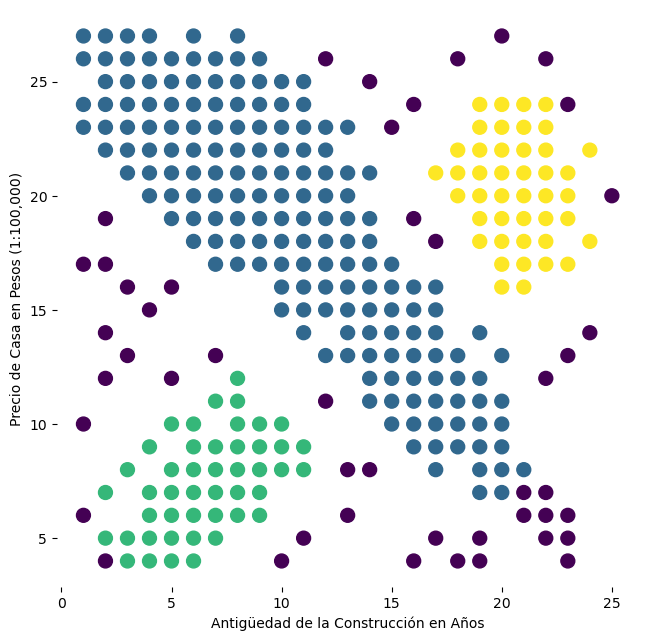

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

# Cargar datos
datos = np.loadtxt("casas.csv", delimiter=",")

# Identificar Clusters
clusters = DBSCAN(eps=2, min_samples=10).fit_predict(datos)
print(clusters)

# Gráfica de matplotlib para mostrar los Clusters
plt.figure(figsize=(7.5, 7.5))
plt.scatter(datos[:, 0], datos[:, 1], c=clusters, s=100)
plt.xlabel("Antigüedad de la Construcción en Años")
plt.ylabel("Precio de Casa en Pesos (1:100,000)")
plt.box(False)
plt.show()